### 馬達論文研究
### 第五步 重新模型建立
### 馬達C 11000RPM
### CNN_VGG 
### 10種工況

In [1]:
# 匯入所需函式庫
import os
import logging
import absl.logging
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder, RobustScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Input, Concatenate, Add, Activation, GlobalAveragePooling1D, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
from gpu_utils import device_scope, DEVICE
warnings.filterwarnings("ignore")

In [2]:
# 資料準備與處理
def load_and_preprocess_data(base_dir, screws_list):
    datasets = []
    for screws in screws_list:
        file_path = os.path.join(base_dir, f'{screws}\\T1_Group_feature_data.csv')
        if os.path.exists(file_path):
            dataset = pd.read_csv(file_path)
            dataset['screws'] = screws
            datasets.append(dataset)
        else:
            print(f"檔案未找到: {file_path}")
    return datasets

In [3]:
# 新資料
def load_and_preprocess_newdata(base_dir, screws_list):
    datasets = []
    for screws in screws_list:
        file_path = os.path.join(base_dir, f'{screws}\\T1_Group_feature_data.csv')
        if os.path.exists(file_path):
            dataset = pd.read_csv(file_path)
            dataset['screws'] = screws
            datasets.append(dataset)
        else:
            print(f"檔案未找到: {file_path}")
    return datasets

In [4]:
# 加載資料
rootDir = os.getcwd()
myfeatureDirectory = f'{rootDir}\\階段1\\myfeature\\T1\\11000rpm'

screws_list = ['8screws', '1screws', '2screws', '3screws', '4screws']
datasets_T1 = load_and_preprocess_data(myfeatureDirectory, screws_list)

In [5]:
myfeatureDirectory2 = f'{rootDir}\\階段1\\myfeature\\T1\\11000rpm'

screws_list2 = ['5screws', '6screws', '7screws', '3_14screws', '4_146screws']
datasets_T2 = load_and_preprocess_newdata(myfeatureDirectory2, screws_list2)

In [6]:
# 合併資料
combined_data = pd.concat(datasets_T1 + datasets_T2, ignore_index=True)

In [7]:
# **手動定義標籤順序**
desired_order = ['8screws', '1screws', '2screws', '3screws', '4screws', '5screws', '6screws', '7screws', '3_14screws', '4_146screws']
label_mapping = {screw: idx for idx, screw in enumerate(desired_order)}
combined_data['screws'] = combined_data['screws'].map(label_mapping)

In [8]:
# 標籤編碼
le_screws = LabelEncoder()
combined_data['screws'] = le_screws.fit_transform(combined_data['screws'])

In [9]:
# 確認標籤映射是否正確
print("自訂 Label Mapping:")
for label, num in label_mapping.items():
    print(f"{label}: {num}")

自訂 Label Mapping:
8screws: 0
1screws: 1
2screws: 2
3screws: 3
4screws: 4
5screws: 5
6screws: 6
7screws: 7
3_14screws: 8
4_146screws: 9


In [10]:
# 資料分割
X = combined_data.drop(['screws'], axis=1).values
y_screws = combined_data['screws'].values

In [11]:
# 劃分訓練與測試集
X_train, X_test, y_train_screws, y_test_screws = train_test_split(
    X, y_screws, test_size=0.2, random_state=42
)

In [12]:
# 標準化特徵
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
# 建立 VGG16 模型
def build_vgg16_model(input_shape, num_classes):
    # 輸入層
    X_input = Input(shape=input_shape)

    # 第一層卷積
    X = Conv1D(32, kernel_size=3, activation='relu', padding='same')(X_input)

    # 第二層卷積
    X = Conv1D(32, kernel_size=3, activation='relu', padding='same')(X)
    X = MaxPooling1D(pool_size=2, strides=2)(X)

    # 第三層卷積
    X = Conv1D(32, kernel_size=3, activation='relu', padding='same')(X)
    
    # 第四層卷積
    X = Conv1D(32, kernel_size=3, activation='relu', padding='same')(X)
    X = MaxPooling1D(pool_size=2, strides=2)(X)

    # 第五層卷積
    X = Conv1D(32, kernel_size=3, activation='relu', padding='same')(X)
    
    # 第六層卷積
    X = Conv1D(32, kernel_size=3, activation='relu', padding='same')(X)

    # 第七層卷積
    X = Conv1D(32, kernel_size=3, activation='relu', padding='same')(X)
    X = MaxPooling1D(pool_size=2, strides=2)(X)

    # 第八層卷積
    X = Conv1D(32, kernel_size=3, activation='relu', padding='same')(X)
    
    # 第九層卷積
    X = Conv1D(32, kernel_size=3, activation='relu', padding='same')(X)

    # 第十層卷積
    X = Conv1D(32, kernel_size=3, activation='relu', padding='same')(X)
    X = MaxPooling1D(pool_size=2, strides=2)(X)

    # 第十一層卷積
    X = Conv1D(32, kernel_size=3, activation='relu', padding='same')(X)
    
    # 第十二層卷積
    X = Conv1D(32, kernel_size=3, activation='relu', padding='same')(X)

    # 第十三層卷積
    X = Conv1D(32, kernel_size=3, activation='relu', padding='same')(X)
    X = MaxPooling1D(pool_size=2, strides=2)(X)

    # 展平層
    X = Flatten()(X)

    # 第十四層全連接層
    X = Dense(64, activation='relu')(X)
    X = Dropout(0.3)(X)

    # 第十五層全連接層
    X = Dense(64, activation='relu')(X)
    X = Dropout(0.3)(X)

    # 第十六層全連接層
    output = Dense(num_classes, activation='softmax', name="Screw_Number_Output")(X)


    # 定義模型
    model = Model(inputs=X_input, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=["sparse_categorical_crossentropy"],
        metrics=["accuracy"]
    )
    return model

In [14]:
# 模型參數
num_screw_classes = len(np.unique(y_train_screws))

In [15]:
print(f"[Training] Device: {DEVICE}")
with device_scope():
    # 建立與訓練模型
    vgg16_model = build_vgg16_model((X_train.shape[1], 1), num_screw_classes)
    history = vgg16_model.fit(
        X_train.reshape(X_train.shape[0], X_train.shape[1], 1),
        y_train_screws,
        validation_data=(
            X_test.reshape(X_test.shape[0], X_test.shape[1], 1),
            y_test_screws
        ),
        epochs=100,
        batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
    )

Epoch 1/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1800 - loss: 2.2525 - val_accuracy: 0.4086 - val_loss: 1.5566
Epoch 2/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4557 - loss: 1.4779 - val_accuracy: 0.9138 - val_loss: 0.5051
Epoch 3/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7686 - loss: 0.6828 - val_accuracy: 0.9716 - val_loss: 0.1315
Epoch 4/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8920 - loss: 0.3379 - val_accuracy: 0.9836 - val_loss: 0.0662
Epoch 5/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9264 - loss: 0.2408 - val_accuracy: 0.9871 - val_loss: 0.0410
Epoch 6/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9451 - loss: 0.1954 - val_accuracy: 0.9940 - val_loss: 0.0268
Epoch 7/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9566 - loss: 0.1520 - val_accuracy: 0.9948 - val_loss: 0.0159
Epoch 8/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9627 - loss: 0.1289 - val_acc

In [16]:
# 模型架構
vgg16_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 105, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 105, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 105, 32)        │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 52, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 52, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 52, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 26, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 26, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 26, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 26, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 13, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 13, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 13, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 13, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 6, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 6, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 6, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Screw_Number_Output (Dense)     │ (None, 10)             │           65

 Total params: 145,184 (567.13 KB)

 Trainable params: 48,394 (189.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 96,790 (378.09 KB)

In [17]:
# 評估模型
results = vgg16_model.evaluate(
    X_test.reshape(X_test.shape[0], X_test.shape[1], 1),
    y_test_screws
)
print(f"Screw Number Loss: {results[0]:.4f}, Screw Number Accuracy: {results[1]:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 1.0524e-06
Screw Number Loss: 0.0000, Screw Number Accuracy: 1.0000


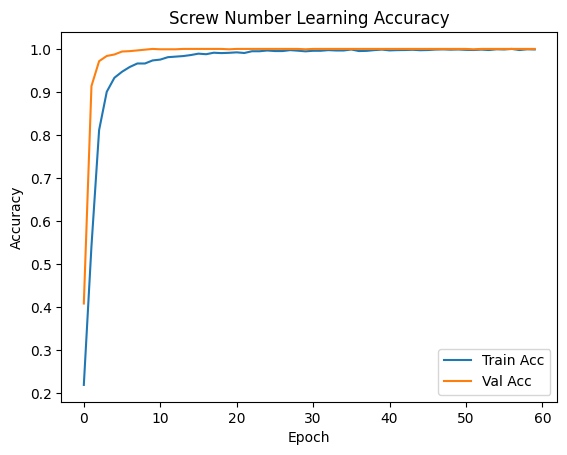

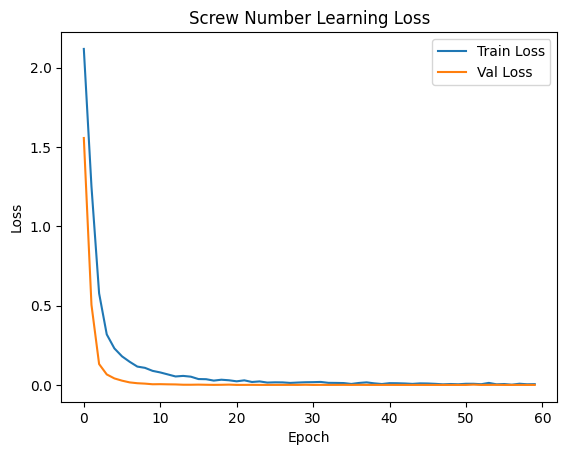

In [18]:
# 繪製學習曲線
plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Screw Number Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Screw Number Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


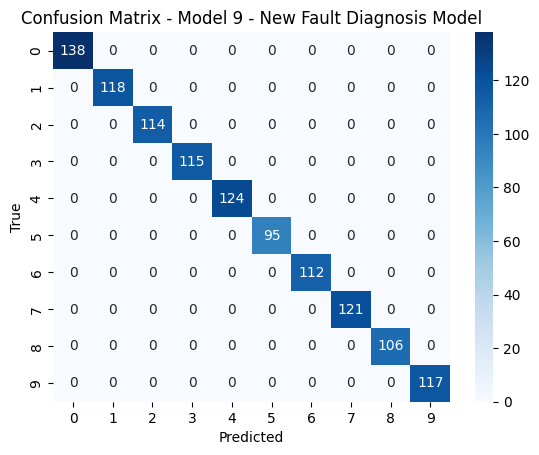

In [19]:
# 混淆矩陣繪製
def plot_confusion_matrix(y_true, y_pred, label_encoder, title):
    """
    繪製混淆矩陣，顯示數字映射標籤
    """
    cm = confusion_matrix(y_true, y_pred)
    numeric_labels = range(len(label_encoder.classes_))  # 使用數字標籤
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=numeric_labels, yticklabels=numeric_labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# 預測並繪製混淆矩陣
y_pred_screw = vgg16_model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1], 1)).argmax(axis=1)
plot_confusion_matrix(y_test_screws, y_pred_screw, le_screws, "Confusion Matrix - Model 9 - New Fault Diagnosis Model")

In [20]:
print(f"[Training] Device: {DEVICE}")
with device_scope():
    # # 定義 K 折數
    # kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    
    # # 儲存每次訓練的結果
    # screw_number_accuracies = []
    
    # # 交叉驗證
    # fold_idx = 1
    # for train_idx, test_idx in kfold.split(X):
    #     # print(f"=== Fold {fold_idx} ===")
    #     X_train, X_test = X[train_idx], X[test_idx]
    #     y_train_screws, y_test_screws = y_screws[train_idx], y_screws[test_idx]
    
    #     # 標準化特徵
    #     scaler = RobustScaler()
    #     X_train = scaler.fit_transform(X_train)
    #     X_test = scaler.transform(X_test)
    
    #     # 建立模型
    #     kfold_model = build_vgg16_model((X_train.shape[1], 1), len(np.unique(y_screws)))
    
    #     # 訓練模型
    #     kfold_history = kfold_model.fit(
    #         X_train.reshape(X_train.shape[0], X_train.shape[1], 1),
    #         y_train_screws,
    #         validation_data=(
    #             X_test.reshape(X_test.shape[0], X_test.shape[1], 1),
    #             y_test_screws
    #         ),
    #         epochs=100,
    #         batch_size=32,
    #         verbose=0,
    #         callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
    #     )
    
    #     # 評估模型
    #     results = kfold_model.evaluate(
    #         X_test.reshape(X_test.shape[0], X_test.shape[1], 1),
    #         y_test_screws,
    #         verbose=0
    #     )
    
    #     screw_number_accuracies.append(results[1])  # 記錄準確率
    
    #     # 顯示當前折的結果
    #     print(f"Fold {fold_idx} Screws Model Accuracy: {results[1] * 100:.2f}%")
    #     fold_idx += 1
    
    
    # # 計算平均與標準差
    # avg_screws_acc = np.mean(screw_number_accuracies) * 100
    # std_screws_acc = np.std(screw_number_accuracies)
    
    
    # # 總結結果
    # print("\n=== Screws Model Results ===")
    # print(f"使用 10-fold Cross Validation 之模型正確率平均值：{avg_screws_acc:.2f}%")
    # print(f"使用 10-fold Cross Validation 之模型正確率標準差：{std_screws_acc:.2f}")